In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import datetime as dt
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, StratifiedKFold, StratifiedShuffleSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, balanced_accuracy_score, confusion_matrix, precision_recall_curve, roc_auc_score, accuracy_score, f1_score, r2_score, mean_absolute_error, mutual_info_score, roc_curve, zero_one_loss
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import LinearSVC, SVC
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE

---
---

## 甚麼都不做, 直接跑隨機森林, 結論是還是要做features selection, 效果會較佳

In [11]:
secom = pd.read_csv(r'C:\Users\No\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=550].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=50].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])  # [[TN, FP],[FN, TP]]
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)


all_metrics = []
for fold, (tr_idx, te_idx) in enumerate(skf.split(X_train, y_train), start=1):
    X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
    y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]

    knn = KNNImputer(n_neighbors=10, weights='distance')
    X_tr_imputed = pd.DataFrame(knn.fit_transform(X_tr), columns=X_tr.columns, index=X_tr.index)
    X_te_imputed = pd.DataFrame(knn.transform(X_te), columns=X_te.columns, index=X_te.index)

    smote = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=42)
    X_balanced, y_balanced = smote.fit_resample(X_tr_imputed, y_tr)

    rf = RandomForestClassifier(n_estimators=1000, min_samples_leaf=15, max_depth=6, min_samples_split=20, random_state=42, n_jobs=-1)
    rf.fit(X_balanced, y_balanced)
    y_pred = rf.predict(X_te_imputed)

    m = compute_metrics(y_te.values, y_pred)
    all_metrics.append(m)

    print(f"fold={fold}, acc={m['acc']:.4f}, FAR={m['FAR']:.4f}")
    print("sensitivy = ", round(m["sensitivity"]*100, 2), "%")
    print("specificity = ", round(m["specificity"]*100, 2), "%")
    print("GM = ", round(m["GM"]*100, 2), "%")
    print("-"*40)

avg = {k: np.nanmean([m[k] for m in all_metrics]) for k in ["acc","FAR","sensitivity","specificity","GM"]}
print("[Mean over 10 folds]")
print(f"acc={avg['acc']:.4f}, FAR={avg['FAR']:.4f}")
print("sensitivy = ", round(avg["sensitivity"]*100, 2), "%")
print("specificity = ", round(avg["specificity"]*100, 2), "%")
print("GM = ", round(avg["GM"]*100, 2), "%")

fold=1, acc=0.8651, FAR=0.0684
sensitivy =  0.0 %
specificity =  93.16 %
GM =  0.0 %
----------------------------------------
fold=2, acc=0.9206, FAR=0.0342
sensitivy =  33.33 %
specificity =  96.58 %
GM =  56.74 %
----------------------------------------
fold=3, acc=0.8889, FAR=0.0513
sensitivy =  11.11 %
specificity =  94.87 %
GM =  32.47 %
----------------------------------------
fold=4, acc=0.9280, FAR=0.0342
sensitivy =  37.5 %
specificity =  96.58 %
GM =  60.18 %
----------------------------------------
fold=5, acc=0.9280, FAR=0.0171
sensitivy =  12.5 %
specificity =  98.29 %
GM =  35.05 %
----------------------------------------
fold=6, acc=0.9280, FAR=0.0427
sensitivy =  50.0 %
specificity =  95.73 %
GM =  69.18 %
----------------------------------------
fold=7, acc=0.8800, FAR=0.0598
sensitivy =  0.0 %
specificity =  94.02 %
GM =  0.0 %
----------------------------------------
fold=8, acc=0.9280, FAR=0.0256
sensitivy =  25.0 %
specificity =  97.44 %
GM =  49.35 %
-------------

---
---
## 二階段的logistic regression, 還是未獲得可用解（實務上沒收斂）
#### 可能要做降維或做L1, L2懲罰


In [46]:
secom = pd.read_csv(r'C:\Users\No\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=550].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=50].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

target_fold = 6
for fold, (tr_idx, te_idx) in enumerate(skf.split(X_train, y_train), start=1):
    if fold != target_fold:
        continue

    X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
    y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]

    # 1) KNN 只 fit 在當折 train
    knn = KNNImputer(n_neighbors=10, weights='distance')
    X_tr_imp = pd.DataFrame(knn.fit_transform(X_tr), columns=X_tr.columns, index=X_tr.index)
    X_te_imp = pd.DataFrame(knn.transform(X_te), columns=X_te.columns, index=X_te.index)

    l1 = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, max_iter=2000, random_state=42)
    l1.fit(X_tr_imp, y_tr)
    coef = pd.Series(l1.coef_.ravel(), index=X_tr_imp.columns)
    selected = coef[coef != 0].index.tolist()
    if len(selected) == 0:
        selected = list(X_tr_imp.columns)

    # 3) 標準化（只用 train 估參數）
    scaler = StandardScaler()
    X_tr_sel = X_tr_imp[selected]
    X_te_sel = X_te_imp[selected]
    X_tr_z = pd.DataFrame(scaler.fit_transform(X_tr_sel), columns=selected, index=X_tr_sel.index)
    X_te_z = pd.DataFrame(scaler.transform(X_te_sel), columns=selected, index=X_te_sel.index)

    # 4) SMOTE 只在 train 上；採 0.7 打破對稱
    smote = SMOTE(sampling_strategy=0.7, k_neighbors=5, random_state=42)
    X_bal, y_bal = smote.fit_resample(X_tr_z, y_tr)

    # 6) 當折 train 上估計 Logit 並印 summary（無懲罰）
    Xb = sm.add_constant(X_bal, has_constant='add')
    res = sm.Logit(y_bal.values, Xb).fit(method='bfgs', maxiter=2000, disp=True)
    print("\n========== statsmodels Logit 第六折 summary ==========")
    print(res.summary())
    break

Optimization terminated successfully.
         Current function value: 0.000014
         Iterations: 845
         Function evaluations: 852
         Gradient evaluations: 852

========== statsmodels Logit 第六折 summary ==========
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 1790
Model:                          Logit   Df Residuals:                     1606
Method:                           MLE   Df Model:                          183
Date:                Tue, 23 Sep 2025   Pseudo R-squ.:                   1.000
Time:                        22:14:02   Log-Likelihood:              -0.024192
converged:                       True   LL-Null:                       -1212.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------

---
---


## 目前最好的一次fold, 來做analysis, 也是一種方法

In [18]:
secom = pd.read_csv(r'C:\Users\No\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=550].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=50].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])  # [[TN, FP],[FN, TP]]
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

def tri_class(y_proba_fail, low, high):
    """
    輸入 y_proba
    回傳 tri_class {-1:pass, 0:not sure, 1:Fail}
    """
    if not (0<=low<high<=1):
        raise ValueError('low必須<high, 且都在[0, 1]')
    tri = np.where(y_proba_fail<=low, -1, np.where(y_proba_fail>=high,1 ,0))
    return tri

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

selected_by_fold = {}
all_metrics = []
for fold, (tr_idx, te_idx) in enumerate(skf.split(X_train, y_train), start=1):
    X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
    y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]

    knn = KNNImputer(n_neighbors=10, weights='distance')
    X_tr_imputed = pd.DataFrame(knn.fit_transform(X_tr), columns=X_tr.columns, index=X_tr.index)
    X_te_imputed = pd.DataFrame(knn.transform(X_te), columns=X_te.columns, index=X_te.index)

    l1 = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, max_iter=2000, random_state=42)
    l1.fit(X_tr_imputed, y_tr)

    coef = pd.Series(l1.coef_.ravel(), index=X_tr_imputed.columns)
    selected = coef[coef != 0].index.tolist()
    if len(selected) == 0:
        selected = list(X_tr_imputed.columns)

    selected_by_fold[fold] = selected

    coef_sel = coef.loc[selected]
    df_rank = (pd.DataFrame({"feature": coef_sel.index, "coef": coef_sel.values}).assign(l1_abs=lambda d: d["coef"].abs()).sort_values("l1_abs", ascending=False).reset_index(drop=True))
    df_rank["rank_l1_abs"] = np.arange(1, len(df_rank)+1)

    if fold == 6:
        print(f"[Fold 6] selected features = {len(selected)}")
        print("[Fold 6] order by |coef| (descending):")
        print(df_rank[["rank_l1_abs","feature","coef","l1_abs"]].head(30).to_string(index=False))
        print("（排序標準：|L1 係數| 由大到小）")

    X_tr_selected = X_tr_imputed[selected].copy()
    X_te_selected = X_te_imputed[selected].copy()

    smote = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=42)
    X_balanced, y_balanced = smote.fit_resample(X_tr_selected, y_tr)

    rf = RandomForestClassifier(n_estimators=1000, min_samples_leaf=15, max_depth=6, min_samples_split=20, random_state=42, n_jobs=-1)
    rf.fit(X_balanced, y_balanced)
    y_pred = rf.predict(X_te_selected)

    if fold == 6:
        y_prob = rf.predict_proba(X_te_selected)[:, 1]
        tri = tri_class(y_prob, low=0.3, high=0.5)
        out = pd.DataFrame({"y_true": y_te.values, "y_pred_bin": y_pred, "p_fail": y_prob, "tri_class": tri}, index=X_te_selected.index)
        print(out.head())
        print("tri_class counts:\n", out["tri_class"].value_counts().sort_index())
        
        y_true_s = y_te.rename("y_true")
        y_pred_s = pd.Series(y_pred, index=X_te_selected.index, name="y_pred")
        fold6_secom_result = pd.concat([X_te_selected, y_true_s, y_pred_s], axis=1)
        print(fold6_secom_result.head(1))
        fold6_secom_test = secom.loc[X_te_selected.index].copy()
        fold6_secom_test["y_true"] = y_true_s
        fold6_secom_test["y_pred"] = y_pred_s
        print(confusion_matrix(y_te, y_pred, labels=[0, 1]))
        
    m = compute_metrics(y_te.values, y_pred)
    all_metrics.append(m)

    print(f"fold={fold}, acc={m['acc']:.4f}, FAR={m['FAR']:.4f}")
    print("sensitivy = ", round(m["sensitivity"]*100, 2), "%")
    print("specificity = ", round(m["specificity"]*100, 2), "%")
    print("GM = ", round(m["GM"]*100, 2), "%")
    print("-"*40)

avg = {k: np.nanmean([m[k] for m in all_metrics]) for k in ["acc","FAR","sensitivity","specificity","GM"]}
print("[Mean over 10 folds]")
print(f"acc={avg['acc']:.4f}, FAR={avg['FAR']:.4f}")
print("sensitivy = ", round(avg["sensitivity"]*100, 2), "%")
print("specificity = ", round(avg["specificity"]*100, 2), "%")
print("GM = ", round(avg["GM"]*100, 2), "%")

fold=1, acc=0.8651, FAR=0.0684
sensitivy =  0.0 %
specificity =  93.16 %
GM =  0.0 %
----------------------------------------
fold=2, acc=0.9048, FAR=0.0513
sensitivy =  33.33 %
specificity =  94.87 %
GM =  56.24 %
----------------------------------------
fold=3, acc=0.8730, FAR=0.0684
sensitivy =  11.11 %
specificity =  93.16 %
GM =  32.17 %
----------------------------------------
fold=4, acc=0.9040, FAR=0.0598
sensitivy =  37.5 %
specificity =  94.02 %
GM =  59.38 %
----------------------------------------
fold=5, acc=0.9200, FAR=0.0342
sensitivy =  25.0 %
specificity =  96.58 %
GM =  49.14 %
----------------------------------------
[Fold 6] selected features = 183
[Fold 6] order by |coef| (descending):
 rank_l1_abs feature      coef   l1_abs
           1    x446  2.168428 2.168428
           2    x178 -1.616071 1.616071
           3    x334  1.588997 1.588997
           4    x407  0.857853 0.857853
           5    x337 -0.711831 0.711831
           6     x15 -0.653757 0.653757
    

---
---

## 調整X, y在cv上的比例（進行中）

<Axes: xlabel='pca1', ylabel='pca2'>

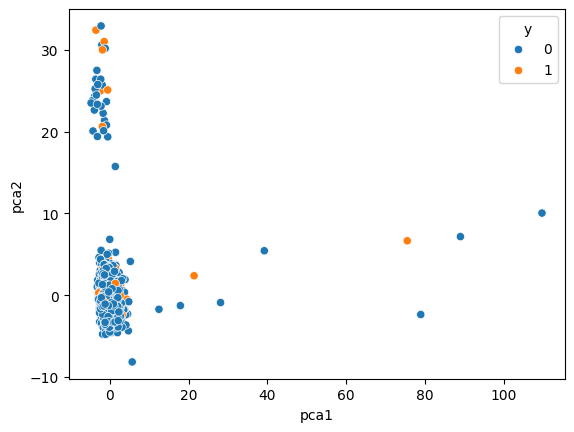

In [22]:
secom = pd.read_csv(r'C:\Users\User\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=550].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=50].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
scaler = StandardScaler()
pca = PCA(n_components=10, random_state=42)

X_imputed = imputer.fit_transform(X)
X_scaled = scaler.fit_transform(X_imputed)
X_pca = pca.fit_transform(X_scaled)

df = pd.DataFrame(X_pca, columns=['pca1', 'pca2', 'pca3', 'pca4', 'pca5', 'pca6', 'pca7', 'pca8', 'pca9', 'pca10'])
df['y'] = y
sns.scatterplot(data=df, x='pca1', y='pca2', hue='y')

In [ ]:
clf = LogisticRegression(max_iter=500, class_weight='balanced', random_state=42)
clf.fit(X_pca, y)

proba = clf.predict_proba(X_pca)[:,1]

idx_y0 = np.where(proba<=0.20)[0]
idx_y1 = np.where(proba>=0.80)[0]

X_y0 = X.iloc[idx_y0].copy()
X_y1 = X.iloc[idx_y1].copy()

purity_y0 = y.iloc[idx_y0].mean()
purity_y1 = y.iloc[idx_y1].mean() 

In [ ]:
base = y.mean()

purity_y0 = y.iloc[idx_y0].mean() if len(idx_y0)>0 else np.nan
purity_y1 = y.iloc[idx_y1].mean() if len(idx_y1)>0 else np.nan

print(f"n_y0={len(idx_y0)}, purity_y0={purity_y0:.3f}  |  n_y1={len(idx_y1)}, purity_y1={purity_y1:.3f}  |  base={base:.3f}")


n_y0=38, purity_y0=0.000  |  n_y1=43, purity_y1=0.209  |  base=0.066


In [ ]:
clf.classes_, proba.min(), proba.max(), proba.mean()

(array([0, 1]), 0.014938047897643384, 0.9999388975507139, 0.45562502059841486)

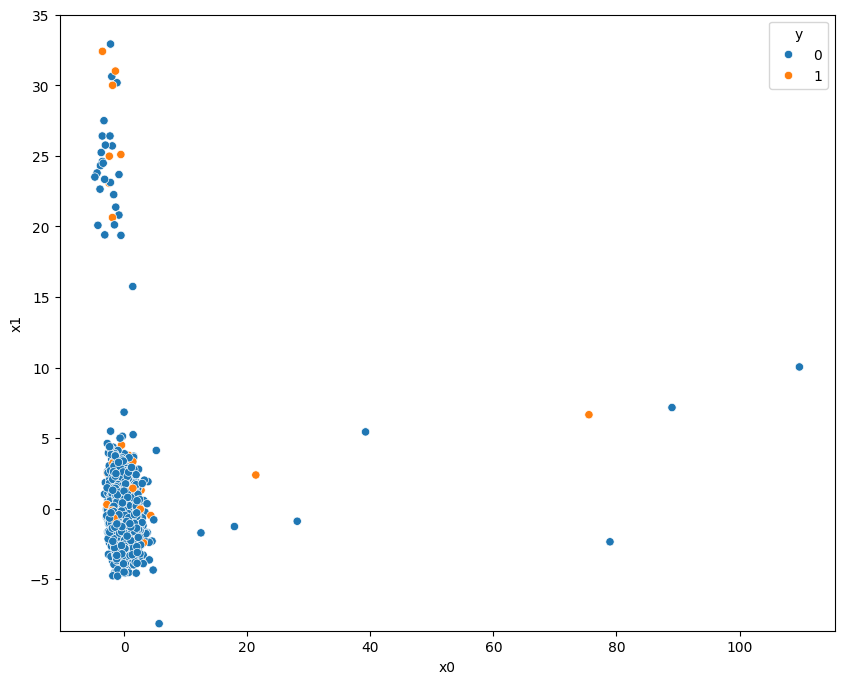

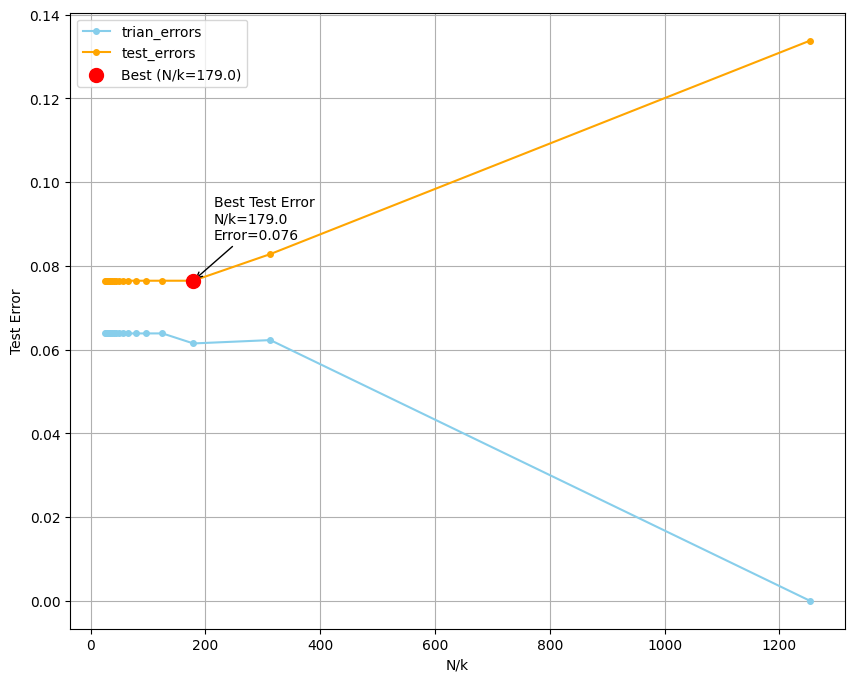

In [ ]:
secom = pd.read_csv(r'C:\Users\User\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=550].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=50].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
scaler = StandardScaler()
pca = PCA(n_components=2, random_state=42)

X_imputed = imputer.fit_transform(X)
X_scaled = scaler.fit_transform(X_imputed)
X_pca = pca.fit_transform(X_scaled)

knc = KNeighborsClassifier(n_neighbors=10)
knc.fit(X_pca, y)

x_min, x_max = X_pca[:, 0].min()+0.3, X_pca[:, 0].max()
y_min, y_max = X_pca[:, 1].min()-0.5, X_pca[:, 1].max()
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.05))
Z = knc.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

df = pd.DataFrame(X_pca, columns=['x0', 'x1'])
df['y'] = y

plt.figure(figsize=(10, 8))
sns.scatterplot(df, x='x0', y='x1', hue='y')
cs = plt.contour(xx, yy, Z, levels=[0.5])
plt.clabel(cs, inline=True, fmt="ŷ=0.5")
plt.show()

X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=42)

N = len(X_train)
train_errors = []
test_errors = []
effective = []
for k in range(1, 51, 3):
    knc = KNeighborsClassifier(n_neighbors=k)
    knc.fit(X_train, y_train)
    y_pred_train = knc.predict(X_train)
    y_pred_test = knc.predict(X_test)

    err_train = zero_one_loss(y_train, y_pred_train)
    err_test = zero_one_loss(y_test, y_pred_test)

    train_errors.append(err_train)
    test_errors.append(err_test)

    effective.append(N/k)

best_effect = effective[np.argmin(test_errors)]
best_test_error = test_errors[np.argmin(test_errors)]

plt.figure(figsize=(10, 8))
plt.plot(effective, train_errors, marker='o', markersize=4, color='skyblue', label='trian_errors')
plt.plot(effective, test_errors, marker='o', markersize=4, color='orange', label='test_errors')
plt.scatter(best_effect, best_test_error, color="red", s=100, zorder=5, label=f"Best (N/k={best_effect:.1f})")
plt.annotate(f"Best Test Error\nN/k={best_effect:.1f}\nError={best_test_error:.3f}",
             xy=(best_effect, best_test_error),
             xytext=(best_effect*1.2, best_test_error+0.01),
             arrowprops=dict(facecolor='red', arrowstyle="->"))
plt.xlabel("N/k")
plt.ylabel("Test Error")
plt.grid(True)
plt.legend()
plt.show()